In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer

(0.6483961419613219, 0.2388248169898848, 71.40545108240539, 0.366102894070608)

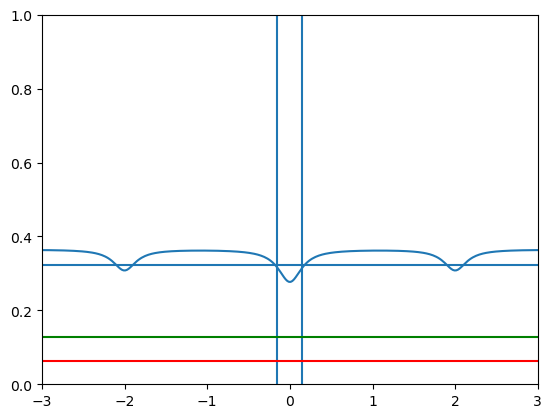

In [ ]:
source = CobaltFe()
absorber = alphaFe()
absorber.thickness_m = 20e-6
absorber.abundance = 0.0212
source.Gamma_ev = 10e-9
source.update_params()
absorber.update_params()

moss = Mossbauer(source, absorber)

v = np.linspace(-10,10,1000)
t = moss.total_transmission_rate(v)


plt.plot(v, t, label = 'Fe')

plt.axhline((1-((t.max()-t.min())/2/t.max()))*moss.non_resonant_attenuation())
plt.axvline(-(source.Gamma + absorber.Gamma)/2)
plt.axvline((source.Gamma + absorber.Gamma)/2)

plt.axhline((1 - source.fs)*moss.non_resonant_attenuation(),color = 'r')
plt.axhline((1 - source.fs*moss.epsilon(absorber.thickness_normalized))*moss.non_resonant_attenuation(),color = 'g')


plt.ylim(0,1)
plt.xlim(-3,3)

vis = moss.epsilon(absorber.thickness_normalized)*source.fs
vis, (t.max()-t.min())/t.max(), source.mossbauer_photon_rate/1e6,moss.non_resonant_attenuation()

In [39]:
rel_sens_10d = 6e-17
rel_sens_1s = rel_sens_10d * np.sqrt(10*24*3600)
eV_sens_1s = rel_sens_1s * 14.4e3
linewidth_eV = eV_sens_1s

visibility_meas = (3830-3050)/3830
visibility_theory_max = (t.max()-t.min())/t.max()

SNR = 7
vis_reduction = 1-0.5/(SNR)
visibility_theory = (t.max()-t.min())/t.max()*vis_reduction

d_source = 10e-3
d_absorber = 5e-3
r_detector = 5e-3

source_solid_angle = np.pi*(r_detector**2)/(d_source**2)
absorber_solid_angle = np.pi*(r_detector**2)/(d_absorber**2)
relative_solid_angle = absorber_solid_angle/source_solid_angle/2
reemitted_fraction = source.fs * moss.epsilon(absorber.thickness_normalized)*1/(absorber.alpha)*relative_solid_angle


print(f"Measured visibility: {visibility_meas:.3f}")
print(f"Theoretical max visibility: {visibility_theory_max:.3f}")
print(f"Theoretical visibility with SNR={SNR}: {visibility_theory:.3f}")
print(f"Relative solid angle: {relative_solid_angle:.3e}")
print(f"Reemitted detected fraction: {reemitted_fraction:.3f}")

linewidth_eV, source.Gamma + absorber.Gamma

Measured visibility: 0.204
Theoretical max visibility: 0.239
Theoretical visibility with SNR=7: 0.222
Relative solid angle: 2.000e+00
Reemitted detected fraction: 0.159


(8.0310182666957e-10, 0.303125)

In [ ]:
moss.epsilon(absorber.thickness_normalized), source.fs, absorber.fa, 


(0.7853556234696513, 0.8256083264505688, 0.8256083264505688)